## **AMR Interpolation**

Import relevant libraries:

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import struct

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from tqdm import tqdm

#### Data reading/formatting

In [39]:
acData = np.empty((4608,2,8,8,8))
bData = np.empty((4608,1,8,8,8))


with open("data.raw", "rb") as file:
    for n in range(4608):
        for k in range(8):
            for j in range(8):
                for i in range(8):
                    acData[n,0,i,j,k] = struct.unpack('<f', file.read(4))[0]         

        for k in range(8):
            for j in range(8):
                for i in range(8):
                    acData[n,1,i,j,k] = struct.unpack('<f', file.read(4))[0]

        for k in range(8):
            for j in range(8):
                for i in range(8):
                    bData[n,0,i,j,k] = struct.unpack('<f', file.read(4))[0]


X_full = torch.from_numpy(acData).float()
print(torch.mean(X_full))
print(torch.std(X_full))
y_full = torch.from_numpy(bData).float()
print(torch.mean(y_full))
print(torch.std(y_full))

class CombustionData(Dataset):
    def __init__(self, X_full, y_full):
        super().__init__()
        X_full = X_full
        y_full = y_full
    
    def __len__(self):
        return len(X_full)

    def __getitem__(self, idx):
        input = X_full[idx]
        output = y_full[idx]
        # sample = {'input': input, 'output': output}
        return input, output

tensor(-9.5058e+09)
tensor(1.8497e+09)
tensor(-9.5055e+09)
tensor(1.8472e+09)


#### Define Model

In [40]:
class CNN(nn.Module):
    def __init__(self, in_channels, out_dim_prod):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv3d(in_channels=in_channels, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv3d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(16*2*2*2, out_dim_prod)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc1(x)
        return x

#### Hyperparameters

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)
in_channels = 2
lr = 3e-4
batch_size = 64
num_epochs = 500
out_dim_prod = 8*8*8

Running on cuda


#### Initializations

In [69]:
transform = transforms.Normalize(torch.mean(X_full), torch.std(X_full))
X_full = transform(X_full)
y_full = transform(y_full)
dataset = CombustionData(X_full, y_full)
train_data, test_data = random_split(dataset, [0.9, 0.1])
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=True)

model = CNN(in_channels, out_dim_prod).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

#### Train, test functions

In [70]:
def train(model, criterion, optimizer, loader, epochs):

    loss_hist = []
    
    for epoch in range(epochs):
        for idx, (data, targets) in enumerate(tqdm(train_loader)):
            data = data.to(device)
            targets = targets.to(device)
            targets = targets.reshape(targets.shape[0], -1)

            scores = model(data)
            loss = criterion(scores, targets)

            optimizer.zero_grad()
            loss.backward()

            optimizer.step()

        loss_hist.append(loss.item())

    return loss_hist

# def check_performace(loader, model):
#     num_correct = 

#### Learn model

In [71]:
loss_hist = train(model, criterion, optimizer, train_loader, num_epochs)

100%|██████████████████████████████████████████████████████████████████████████████████| 65/65 [00:00<00:00, 781.05it/s]


#### Plot losses

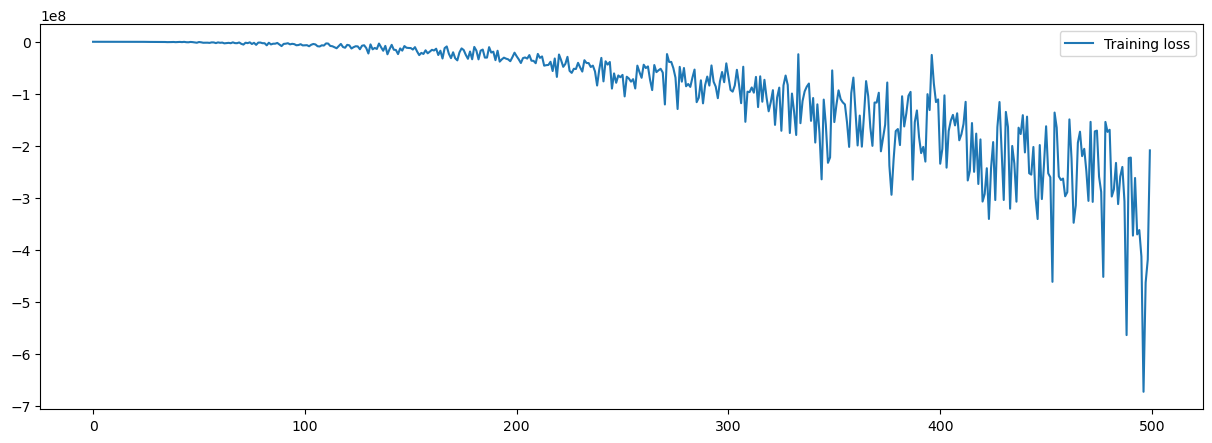

In [72]:
plt.figure(figsize = (15,5))
plt.plot(range(num_epochs), loss_hist, label='Training loss')
plt.legend()